# NoteIQ OCR Testing Notebook

This notebook tests the NoteIQ OCR and AI enrichment app.

## Setup
1. Start your Flask app: `python app_simple.py &`
2. Run the cells below to test OCR and enrichment


In [11]:
# Import required libraries
import requests
import base64
import json
import os
from IPython.display import Image, display, JSON


## 1. Test Server Status


In [12]:
# Test if Flask app is running
try:
    response = requests.get('http://localhost:5001/', timeout=5)
    print(f"✅ Server Status: {response.status_code}")
    print(f"Response: {response.json()}")
except requests.exceptions.RequestException as e:
    print(f"❌ Server Error: {e}")
    print("Make sure to run: python app_simple.py &")


✅ Server Status: 404
❌ Server Error: Expecting value: line 1 column 1 (char 0)
Make sure to run: python app_simple.py &


## 2. Test OCR with Your Image


📸 Loading image: idea-mapping.png
✅ Image encoded (length: 504308 characters)


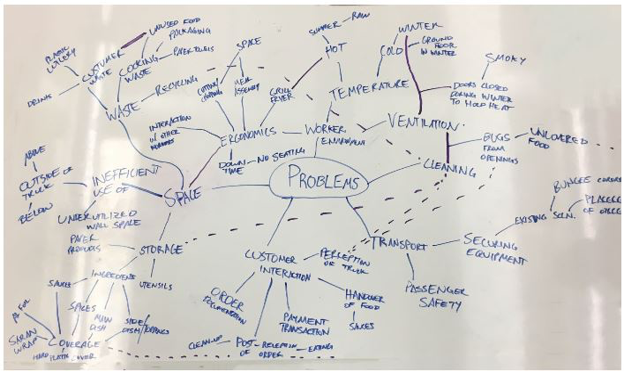

In [13]:
# Load and encode your image
image_path = 'idea-mapping.png'

if os.path.exists(image_path):
    print(f"📸 Loading image: {image_path}")
    
    # Convert image to base64
    with open(image_path, 'rb') as img_file:
        img_base64 = base64.b64encode(img_file.read()).decode('utf-8')
    
    print(f"✅ Image encoded (length: {len(img_base64)} characters)")
    
    # Display the image
    display(Image(image_path, width=400))
else:
    print(f"❌ Image not found: {image_path}")


In [14]:
# Test OCR endpoint
def test_ocr(image_base64):
    """Test the OCR endpoint with base64 image"""
    
    url = 'http://localhost:5001/ocr'
    data = {'image_base64': image_base64}
    
    try:
        print("🔄 Sending OCR request...")
        response = requests.post(url, json=data, timeout=10)
        
        print(f"📊 Status Code: {response.status_code}")
        
        if response.status_code == 200:
            result = response.json()
            print("✅ OCR Success!")
            print(f"📝 Extracted Text:\n{result['extracted_text']}")
            return result['extracted_text']
        else:
            print(f"❌ OCR Error: {response.text}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"❌ Request Error: {e}")
        return None

# Test OCR if image is loaded
if 'img_base64' in locals():
    extracted_text = test_ocr(img_base64)
else:
    print("❌ No image loaded. Run the previous cell first.")


🔄 Sending OCR request...
📊 Status Code: 200
✅ OCR Success!
📝 Extracted Text:
DRINKS
PLANK
WUTLERY
"CUSTUMER"
UNUSED KOD
PACKAGING
COOKING ATERPES
WASE
WASTE-RECYCLING
SUMMER-RAW
WINTER
GROUND
FOOR
W MATER
FRIER TEMPERATURE
SPACE
HOT
MEM
GRICE
INTERACTION
ERGONOMICS
-WORKER
DOWN-NO SEATING
EMWAN
TWE
SPACE
OUTSIDE OR
Trick
TE
SARAN
WRAP
INEFFICIENT
USE OF
UNTERULIZED
WALL SPALE
SACH
PAVER
Haras
INGREDIENTS
SALES
MW
DISH
COVERAGE
PLAIN WER
STORAGE
UTENSILS
PROBLEMS
SMOKY
•Dooks Closed
FORING WWE
TO HOLD PEA
VENTILATION
BUGS
FROM
OPENINGS
CLEANING
UNCOVERED..
FOOD
BUNGEE
EXISTING SEN
SECURING
EQUIPMENT
PASSENGER
SAFETY
CUSTOMER
INTERACTION
ORDER
POLEON
GEAN
TRANSPORT
PERCEPTION
of Thick
PAYMENT
TRANSACTION
POST-RELEMEN
Ok opper --
HANDOVER
Of Foop
SAUCES
CORSAY
·PLACECE
OF ONCE


## 3. Test Text Enrichment


In [15]:
# Test enrichment endpoint
def test_enrichment(text):
    """Test the enrichment endpoint with text"""
    
    url = 'http://localhost:5001/enrich'
    data = {'text': text}
    
    try:
        print("🔄 Sending enrichment request...")
        response = requests.post(url, json=data, timeout=10)
        
        print(f"📊 Status Code: {response.status_code}")
        
        if response.status_code == 200:
            result = response.json()
            print("✅ Enrichment Success!")
            print(f"📝 Original Text:\n{result['original_text']}\n")
            print(f"🎯 Enriched Output:\n{result['enriched_output']}")
            return result
        else:
            print(f"❌ Enrichment Error: {response.text}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"❌ Request Error: {e}")
        return None

# Test with sample text or extracted text
sample_text = "This is a test brainstorm about creating a new mobile app for productivity. Key ideas include user interface design, database architecture, and marketing strategy."

if 'extracted_text' in locals() and extracted_text:
    print("Using extracted text from OCR:")
    enrichment_result = test_enrichment(extracted_text)
else:
    print("Using sample text:")
    enrichment_result = test_enrichment(sample_text)


Using extracted text from OCR:
🔄 Sending enrichment request...
📊 Status Code: 200
✅ Enrichment Success!
📝 Original Text:
DRINKS
PLANK
WUTLERY
"CUSTUMER"
UNUSED KOD
PACKAGING
COOKING ATERPES
WASE
WASTE-RECYCLING
SUMMER-RAW
WINTER
GROUND
FOOR
W MATER
FRIER TEMPERATURE
SPACE
HOT
MEM
GRICE
INTERACTION
ERGONOMICS
-WORKER
DOWN-NO SEATING
EMWAN
TWE
SPACE
OUTSIDE OR
Trick
TE
SARAN
WRAP
INEFFICIENT
USE OF
UNTERULIZED
WALL SPALE
SACH
PAVER
Haras
INGREDIENTS
SALES
MW
DISH
COVERAGE
PLAIN WER
STORAGE
UTENSILS
PROBLEMS
SMOKY
•Dooks Closed
FORING WWE
TO HOLD PEA
VENTILATION
BUGS
FROM
OPENINGS
CLEANING
UNCOVERED..
FOOD
BUNGEE
EXISTING SEN
SECURING
EQUIPMENT
PASSENGER
SAFETY
CUSTOMER
INTERACTION
ORDER
POLEON
GEAN
TRANSPORT
PERCEPTION
of Thick
PAYMENT
TRANSACTION
POST-RELEMEN
Ok opper --
HANDOVER
Of Foop
SAUCES
CORSAY
·PLACECE
OF ONCE

🎯 Enriched Output:

📝 **NoteIQ Enhanced Analysis**

**🎯 Key Themes & Patterns:**
Problem Identification, Action Items

**📝 Key Sentences Identified:**
• "DRINKS
PLANK
WUT